# BASTION: U.S. Airline Traffic Example

This notebook applies **pybastion** to monthly U.S. international airline
passenger counts (2003–2023), based on Section 6.1 of:

> Cho, J. B. & Matteson, D. S. (2026). *BASTION: A Bayesian Framework for
> Trend and Seasonality Decomposition.* arXiv:2601.18052.

## Why this dataset?

- Long-term **upward trend** in international travel.
- Pronounced **annual seasonality** (peak July/August, trough Jan/Feb).
- Sharp **structural break** in early 2020 (COVID-19 travel restrictions).

> *'BASTION provides a smooth yet adaptive trend, capturing the abrupt
> COVID-19 drop while preserving overall structure.'* — Section 6.1

## What this notebook covers

1. Load and explore the data.
2. Fit BASTION with K = 12 (annual seasonality).
3. Visualise the signal and trend (2016–2023 zoom).
4. Full decomposition.
5. In-sample fit statistics.

**Note:** No R-BASTION reference output is bundled for this dataset.
The simulation-average benchmarks from DGP 4 (Tables 2 & 3) are included
in the metrics section as context.

In [1]:
import os, sys
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

NOTEBOOK_DIR = os.path.abspath(os.getcwd())
PROJECT_DIR  = os.path.abspath(os.path.join(NOTEBOOK_DIR, ".."))
OUTPUT_DIR   = os.path.join(PROJECT_DIR, "outputs")
os.makedirs(OUTPUT_DIR, exist_ok=True)

sys.path.insert(0, PROJECT_DIR)
from pybastion import fit_BASTION
from pybastion.datasets import load_airtraffic as _load_raw

QUICK_MODE = False

if QUICK_MODE:
    nsave, nburn, nskip, nchains = 50, 50, 0, 1
else:
    nsave, nburn, nskip, nchains = 2000, 5000, 4, 2

nstot = nburn + (nskip + 1) * nsave
print(f"pybastion loaded from: {PROJECT_DIR}")
print(f"QUICK_MODE={QUICK_MODE}: {nstot:,} steps × {nchains} chain(s)")

pybastion loaded from: /media/daniel/Extreme SSD/Projects/pyBASTION
QUICK_MODE=False: 15,000 steps × 2 chain(s)


## 1. Load and Explore the Data

Monthly passenger counts (millions) for U.S. international routes, sourced
from Kaggle (Yan, 2023).  Bundled via `pybastion.datasets.load_airtraffic()`.

Observations : 249 monthly records
Date range   : 2003-01-01 to 2023-09-01
Pax range    : 0.1 to 12.4


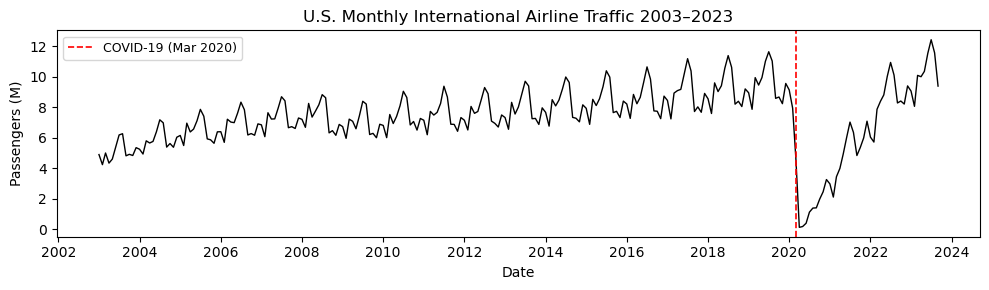

In [2]:
def load_airtraffic():
    df = _load_raw()
    df["date"] = pd.to_datetime(
        df["Year"].astype(int).astype(str) + "-"
        + df["Month"].astype(int).astype(str).str.zfill(2) + "-01"
    )
    return df.rename(columns={"Int_Pax": "pax"})[["date", "pax"]].reset_index(drop=True)

air = load_airtraffic()
print(f"Observations : {len(air)} monthly records")
print(f"Date range   : {air['date'].min().date()} to {air['date'].max().date()}")
print(f"Pax range    : {air['pax'].min():,.1f} to {air['pax'].max():,.1f}")

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(air["date"], air["pax"], lw=1.0, color="black")
ax.axvline(pd.Timestamp("2020-03-01"), color="red", ls="--", lw=1.2,
           label="COVID-19 (Mar 2020)")
ax.set_xlabel("Date"); ax.set_ylabel("Passengers (M)")
ax.set_title("U.S. Monthly International Airline Traffic 2003–2023")
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.legend(fontsize=9); fig.tight_layout()
plt.show()

## 2. Fit BASTION

| Parameter | Quick | Full | Meaning |
|-----------|-------|------|---------|
| `Ks` | `[12]` | `[12]` | Annual seasonality |
| `Outlier` | `True` | `True` | Horseshoe+ outlier component |
| `nsave` | 50 | 2 000 | Saved draws |
| `nburn` | 50 | 5 000 | Burn-in |
| `nskip` | 0 | 4 | Thinning |
| `nchains` | 1 | 2 | Independent chains |

In [3]:
result  = fit_BASTION(
    air["pax"].values,
    Ks=[12],
    Outlier=True,
    cl=0.95,
    obsSV="const",
    nsave=nsave, nburn=nburn, nskip=nskip, nchains=nchains,
    seed=40,
)
summary = result["summary"]
print("Components:", [k for k in summary if k.endswith("_sum")])

Chain 1


MCMC: 100%|██████████| 15000/15000 [03:19<00:00, 75.01it/s]


Chain 2


MCMC: 100%|██████████| 15000/15000 [03:25<00:00, 73.02it/s]


Components: ['Trend_sum', 'Seasonal12_sum', 'Outlier_sum', 'Signal_sum']


## 3. Signal: Trend + Seasonality (2016–2023)

Black = posterior mean signal; red = trend; grey = 95 % credible region.

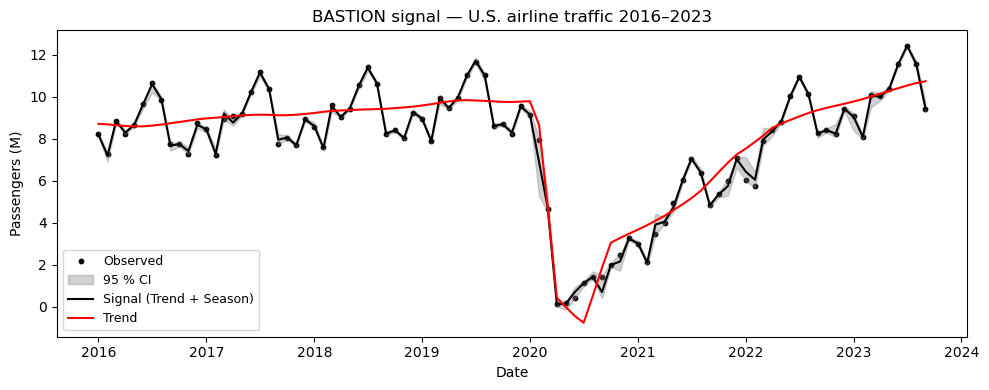

In [4]:
mask        = air["date"] >= "2016-01-01"
dates_sub   = air["date"].values[mask]
pax_sub     = air["pax"].values[mask]
idx         = np.where(mask)[0]

trend_mean  = np.asarray(summary["Trend_sum"]["Mean"]).ravel()[idx]
trend_lo    = np.asarray(summary["Trend_sum"]["CR_lower"]).ravel()[idx]
trend_hi    = np.asarray(summary["Trend_sum"]["CR_upper"]).ravel()[idx]
signal_mean = np.asarray(summary["Signal_sum"]["Mean"]).ravel()[idx]
signal_lo   = np.asarray(summary["Signal_sum"]["CR_lower"]).ravel()[idx]
signal_hi   = np.asarray(summary["Signal_sum"]["CR_upper"]).ravel()[idx]

fig, ax = plt.subplots(figsize=(10, 4))
ax.scatter(dates_sub, pax_sub, s=10, color="black", zorder=1, label="Observed")
ax.fill_between(dates_sub, signal_lo, signal_hi, color="grey", alpha=0.35,
                zorder=2, label="95 % CI")
ax.plot(dates_sub, signal_mean, lw=1.5, color="black", zorder=3,
        label="Signal (Trend + Season)")
ax.plot(dates_sub, trend_mean,  lw=1.5, color="red",   zorder=4, label="Trend")
ax.set_xlabel("Date"); ax.set_ylabel("Passengers (M)")
ax.set_title("BASTION signal — U.S. airline traffic 2016–2023")
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.legend(fontsize=9); fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "airtraffic_signal.pdf"), dpi=150,
            bbox_inches="tight")
plt.show()

## 4. Full Decomposition

Observed + signal · Trend · Seasonality (K = 12) · Remainder.

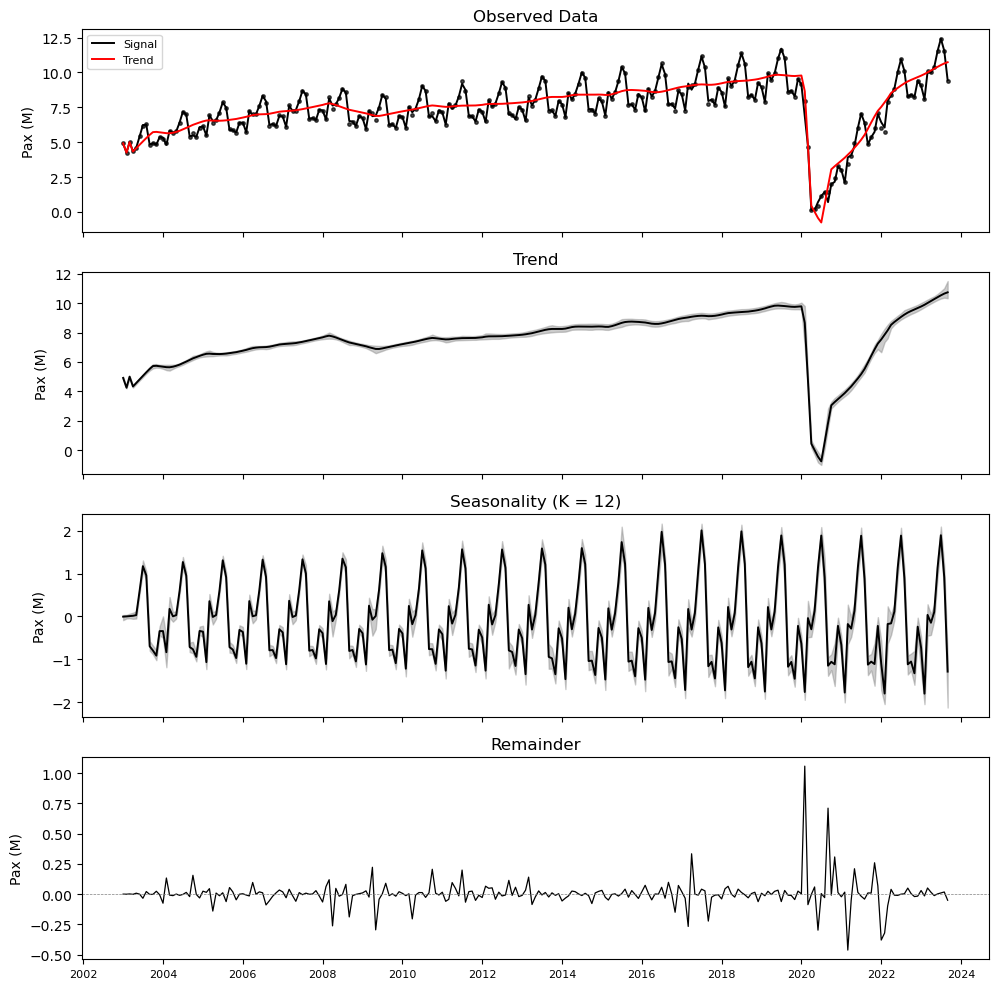

In [5]:
dates = air["date"].values
pax   = air["pax"].values

trend_m_all  = np.asarray(summary["Trend_sum"]["Mean"]).ravel()
trend_lo_all = np.asarray(summary["Trend_sum"]["CR_lower"]).ravel()
trend_hi_all = np.asarray(summary["Trend_sum"]["CR_upper"]).ravel()
signal_all   = np.asarray(summary["Signal_sum"]["Mean"]).ravel()
s12_mean     = np.asarray(summary["Seasonal12_sum"]["Mean"]).ravel()
s12_lo       = np.asarray(summary["Seasonal12_sum"]["CR_lower"]).ravel()
s12_hi       = np.asarray(summary["Seasonal12_sum"]["CR_upper"]).ravel()
remainder    = pax - signal_all

fig, axes = plt.subplots(4, 1, figsize=(10, 10), sharex=True)

ax = axes[0]
ax.scatter(dates, pax, s=6, color="black", zorder=2, alpha=0.7)
ax.plot(dates, signal_all,  lw=1.4, color="black", zorder=3, label="Signal")
ax.plot(dates, trend_m_all, lw=1.4, color="red",   zorder=4, label="Trend")
ax.set_title("Observed Data"); ax.set_ylabel("Pax (M)"); ax.legend(fontsize=8)

ax = axes[1]
ax.fill_between(dates, trend_lo_all, trend_hi_all, color="grey", alpha=0.4)
ax.plot(dates, trend_m_all, lw=1.4, color="black")
ax.set_title("Trend"); ax.set_ylabel("Pax (M)")

ax = axes[2]
ax.fill_between(dates, s12_lo, s12_hi, color="grey", alpha=0.4)
ax.plot(dates, s12_mean, lw=1.4, color="black")
ax.set_title("Seasonality (K = 12)"); ax.set_ylabel("Pax (M)")

ax = axes[3]
ax.plot(dates, remainder, lw=0.9, color="black")
ax.axhline(0, color="grey", ls="--", lw=0.5)
ax.set_title("Remainder"); ax.set_ylabel("Pax (M)")

for ax in axes:
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.tick_params(axis="x", labelsize=8)
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "airtraffic_decomposition.pdf"), dpi=150,
            bbox_inches="tight")
plt.show()

## 5. Metrics

### 5a. Simulation benchmarks (Paper Tables 2 & 3, DGP 4)

DGP 4 (piecewise-linear trend, two seasonals, SV, outliers) is the
simulation scenario closest to this application.  Competitors not available
in `pybastion`; shown for reference only.

| Method | Signal MSE | Trend MSE | Seasonal MSE |
|--------|------------|-----------|-------------|
| TBATS             | 11.829 | 11.111 | 5.364 |
| MSTL              | 11.430 | 12.328 | 3.045 |
| STR               | 20.548 | 13.431 | 11.358 |
| **R BASTION (paper)** | **2.877** | **5.210** | **2.562** |

| Component | STR cov. | R BASTION cov. |
|-----------|----------|----------------|
| Signal       | 0.679 | **0.981** |
| Trend        | 0.668 | **0.939** |
| Seasonality  | 0.623 | **0.999** |

*Source: Tables 2 & 3, DGP 4, Cho & Matteson (2026).*

### 5b. In-sample fit — this run

Since no ground truth exists for real data, the table below reports
in-sample statistics.  `Signal = Trend + Seasonality`.

In [6]:
R2 = float(1 - np.var(remainder) / np.var(pax))
rmse = float(np.sqrt(np.mean(remainder ** 2)))
trend_range  = float(trend_m_all.max() - trend_m_all.min())
s12_range    = float(s12_mean.max() - s12_mean.min())
pct_trend    = float(np.var(trend_m_all) / np.var(pax) * 100)
pct_season   = float(np.var(s12_mean)    / np.var(pax) * 100)

fit_stats = pd.DataFrame(
    {
        "Statistic": [
            "Signal R² (in-sample)",
            "Remainder RMSE",
            "Trend: peak-to-trough range [M pax]",
            "Seasonality: peak-to-trough range [M pax]",
            "Trend: share of total variance",
            "Seasonality: share of total variance",
        ],
        "Value": [
            f"{R2:.1%}", f"{rmse:.3f}",
            f"{trend_range:.3f}", f"{s12_range:.3f}",
            f"{pct_trend:.1f}%", f"{pct_season:.1f}%",
        ],
    }
).set_index("Statistic")
print("In-sample fit statistics — this run")
print(fit_stats.to_string())

In-sample fit statistics — this run
                                            Value
Statistic                                        
Signal R² (in-sample)                       99.7%
Remainder RMSE                              0.116
Trend: peak-to-trough range [M pax]        11.491
Seasonality: peak-to-trough range [M pax]   3.811
Trend: share of total variance              85.1%
Seasonality: share of total variance        20.9%
